In [1]:
import pandas as pd
import numpy as np
import glob

In [2]:
users_fold1 = pd.read_csv("ambar_fold1_DMF_test_recommendations.csv", names = ["user", "ranking", "item", "score"])
compat = pd.read_csv("ambar_compat_tail.csv", names = ["user", "item", "compatibility"])

In [12]:
ambar = pd.read_csv("ambar_fold1_MultiVAE_test_recommendations.csv")

In [18]:
compat_tail = compat[compat["item"] == "tail"]

In [19]:
missing = set(users_fold1["user"]) - set(compat_tail["user"])
print(len(missing), "users in fold1 but not in tail")
missing

2 users in fold1 but not in tail


{9150784, 827027261}

In [23]:
compat = pd.concat([compat, pd.DataFrame({"user": list(missing), "item": "tail", "compatibility": 0.0})], ignore_index=True)

In [24]:
compat 

,user,item,compatibility
0,188426181,undefined,0.710526
1,188426181,head,1.000000
2,188426181,female,0.105263
3,188426181,male,0.184211
4,188426181,non-binary,0.000000
...,...,...,...
340748,9150784,female,0.000000
340749,827027261,female,0.000000
340750,968509568,female,0.000000
340751,9150784,tail,0.000000


In [15]:
ambar.drop(columns=['rank'], inplace=True)

In [16]:
ambar

,user_id,item_id,score
0,258268203,348235,16.172680
1,258268203,348210,16.144825
2,258268203,348266,15.648407
3,258268203,30194,15.235500
4,258268203,15496,15.015881
...,...,...,...
299995,497395708,330694,11.644063
299996,497395708,2905662,11.636424
299997,497395708,398431,11.588906
299998,497395708,4962736,11.587101


In [17]:
ambar.to_csv("ambar_fold1_MultiVAE_test_recommendations.csv", index=False, header=False)

In [25]:
compat.to_csv("ambar_compat_tail.csv", index=False, header=False)

In [7]:
ndcg_proxy = pd.read_csv("ambar_fold1_BPR_train_ndcg_proxy.csv")

In [9]:
ndcg_proxy["compat"] = 1 - ndcg_proxy["train_ndcg_proxy@50"]

In [10]:
ndcg_proxy

,user_id,train_ndcg_proxy@50,compat
0,258268203,0.879769,0.120231
1,123997258,0.610558,0.389442
2,312433946,0.986262,0.013738
3,322644968,0.380700,0.619300
4,751889313,0.924797,0.075203
...,...,...,...
5995,313507810,1.000000,0.000000
5996,21229279,1.000000,0.000000
5997,410395762,0.738603,0.261397
5998,669501053,0.117783,0.882217


In [11]:
def power_function(x, k=0.5):
    x = np.array(x)
    d = x - 0.5          
    sign = np.sign(d)
    pushed = sign * 0.5 * (np.abs(2 * d) ** k)
    return 0.5 + pushed

In [42]:
def power_function_mid(x, midpoint=0.2, k=0.5):
    x = np.array(x, dtype=float)
    result = np.empty_like(x)
    
    above = x >= midpoint
    d_above = (x[above] - midpoint) / (1 - midpoint)
    result[above] = midpoint + (1 - midpoint) * (d_above ** k)
    
    below = ~above
    d_below = (midpoint - x[below]) / midpoint  
    result[below] = midpoint - midpoint * (d_below ** k)
    
    return result

In [43]:
ndcg_proxy["transformed"] = power_function_mid(ndcg_proxy["compat"], midpoint = 0.2, k=0.05)

<Axes: title={'center': 'Transformed NDCG Proxy Distribution'}, xlabel='Transformed NDCG Proxy', ylabel='Frequency'>

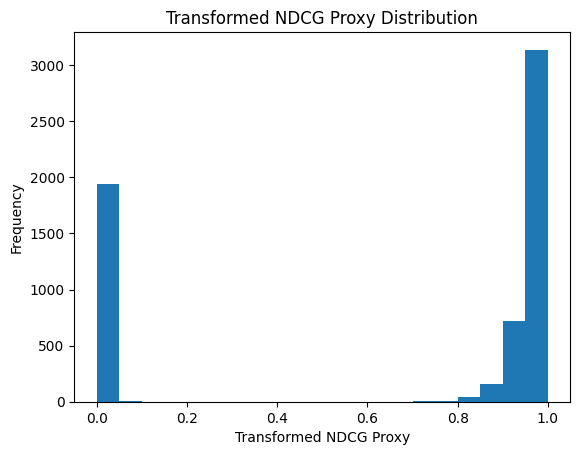

In [44]:
ndcg_proxy["transformed"].plot(kind='hist', bins=20, title="Transformed NDCG Proxy Distribution", xlabel="Transformed NDCG Proxy", ylabel="Frequency")

In [45]:
compats_new = ndcg_proxy[["user_id", "transformed"]].rename(columns={"transformed": "compatibility"})

In [46]:
compats_new["item"] = "consumer_individual"
compats_new["user"] = compats_new["user_id"]
compats_new.drop(columns=["user_id"], inplace=True)
compats_new = compats_new[["user", "item", "compatibility"]]

In [13]:
unique_users = compat['user'].unique()

new_rows = pd.DataFrame({
    'user': unique_users,
    'item': 'llm_individual',
    'compatibility': 1
})

df = pd.concat([compat, new_rows], ignore_index=True)

In [47]:
df =pd.concat([compat, compats_new], ignore_index=True)

In [48]:
df

,user,item,compatibility
0,188426181,undefined,0.710526
1,188426181,head,1.000000
2,188426181,female,0.105263
3,188426181,male,0.184211
4,188426181,non-binary,0.000000
...,...,...,...
346748,313507810,consumer_individual,0.000000
346749,21229279,consumer_individual,0.000000
346750,410395762,consumer_individual,0.903627
346751,669501053,consumer_individual,0.993655


In [49]:
df.to_csv("ambar_individual_compat_80.csv", index=False, header=False)